In [1]:
import time
import matplotlib.pyplot as plt 
import os
os.chdir('../')
import torch
import psutil
import numpy as np
import torch.nn as nn
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
import random 
from decimal import Decimal
import deepwave
import warnings
import torch.nn.functional as F
from functools import partial
from torchaudio.functional import biquad
from scipy.signal import butter
warnings.filterwarnings('ignore')
import os
from ultils.utils import *
os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [2]:
gpu_count = torch.cuda.device_count()
print(f"The number of available GPUs is: {gpu_count}")
if torch.cuda.is_available():
    DEVICE = torch.device("cuda:0")  
    print(f"The selected GPU device is: {torch.cuda.get_device_name(DEVICE)}")
else:
    DEVICE = torch.device("cpu")
    print("No available GPUs detected, switched to using CPU")

The number of available GPUs is: 1
The selected GPU device is: NVIDIA GeForce RTX 4090


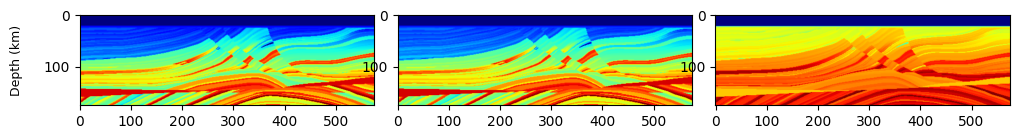

max values: tensor(4766.6040, device='cuda:0') tensor(2752., device='cuda:0') tensor(2626.9998, device='cuda:0')
min values: tensor(1500., device='cuda:0') tensor(800., device='cuda:0') tensor(1009., device='cuda:0')
model shape: torch.Size([176, 575]) torch.Size([176, 575]) torch.Size([176, 575])


In [3]:
######### load data #########
dx = 20

vp_true1 = torch.tensor(np.load('./marmousi_model/vp_truex352x1150x10.npy')).to(DEVICE)
vs_true1 = torch.tensor(np.load('./marmousi_model/vs_truex352x1150x10.npy')).to(DEVICE)
rho_true1 = torch.tensor(np.load('./marmousi_model/rho_truex352x1150x10.npy')).to(DEVICE)


vp_true = vp_true1[::2,::2]
vs_true = vs_true1[::2,::2]
rho_true = rho_true1[::2,::2]


submarine_deep = 22
submarine_vp = 1500                                      #water layer vp
submarine_vs = 800  ##to obay the CFL condition                                         #water layer vs
submarine_rho = 1009
  
vp_true[:submarine_deep,:] = submarine_vp
vs_true[:submarine_deep,:] = submarine_vs
rho_true[:submarine_deep,:] = submarine_rho


fig, ax = plt.subplots(1, 3, figsize=(12, 16))
fig1 = ax[0].imshow(vp_true.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_true.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_true.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()
print("max values:",vp_true.max(),vs_true.max(),rho_true.max())
print("min values:",vp_true.min(),vs_true.min(),rho_true.min())
print("model shape:",vp_true.shape,vs_true.shape,rho_true.shape)

torch.Size([352, 1150])
torch.Size([176, 575]) torch.Size([176, 575]) torch.Size([176, 575])
tensor(4107.6050, device='cuda:0') tensor(1500., device='cuda:0')
tensor(800., device='cuda:0') tensor(2371.5269, device='cuda:0')
tensor(1009., device='cuda:0') tensor(2473.4880, device='cuda:0')


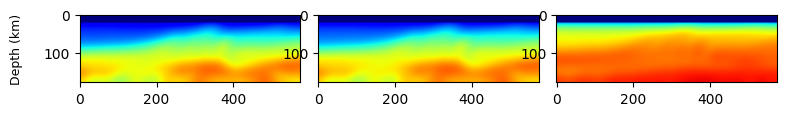

In [4]:
import scipy.ndimage
import scipy.io

sigma = 30

vp_initial = scipy.ndimage.gaussian_filter(vp_true1.cpu().detach().numpy(),sigma=sigma)
vp_initial = torch.tensor(vp_initial)
vp_initial = vp_initial.to(DEVICE)
print(vp_initial.shape)

vs_initial = scipy.ndimage.gaussian_filter(vs_true1.cpu().detach().numpy(),sigma=sigma)
vs_initial = torch.tensor(vs_initial)
vs_initial = vs_initial.to(DEVICE)


rho_initial = scipy.ndimage.gaussian_filter(rho_true1.cpu().detach().numpy(),sigma=sigma)
rho_initial = torch.tensor(rho_initial)
rho_initial = rho_initial.to(DEVICE)


vp_initial = vp_initial[::2,::2]
vs_initial = vs_initial[::2,::2]
rho_initial = rho_initial[::2,::2]


vp_initial[:submarine_deep,:] = submarine_vp
vs_initial[:submarine_deep,:] = submarine_vs
rho_initial[:submarine_deep,:] = submarine_rho

print(vp_initial.shape,vs_initial.shape,rho_initial.shape)
print(vp_initial.max(),vp_initial.min())
print(vs_initial.min(),vs_initial.max())
print(rho_initial.min(),rho_initial.max())

fig, ax = plt.subplots(1, 3, figsize=(9, 12))
fig1 = ax[0].imshow(vp_initial.cpu().numpy(), cmap= 'jet',vmin = vp_true.min(),vmax = vp_true.max())
ax[0].set_ylabel("Depth (km)\n",fontsize=9)
fig2 = ax[1].imshow(vs_initial.cpu().numpy(), cmap= 'jet',vmin = vs_true.min(),vmax = vs_true.max())
fig3 = ax[2].imshow(rho_initial.cpu().numpy(), cmap= 'jet',vmin = rho_true.min(),vmax = rho_true.max())
plt.subplots_adjust(hspace=-0.84,wspace=0.08) 
plt.show()

In [5]:
loss_fn = 'l1'  # Options: 'l1', 'l2', 'lap_l1', 'gau_l1', 
                # Determines the misfit function between synthetic and observed data

##### save path
vp_save_path = f'./rec/reconstruction_small/EFWI_en/{loss_fn}/vp/'
vs_save_path = f'./rec/reconstruction_small/EFWI_en/{loss_fn}/vs/'
rho_save_path = f'./rec/reconstruction_small/EFWI_en/{loss_fn}/rho/'
src_save_path = f'./rec/reconstruction_small/EFWI_en/{loss_fn}/src/'

main_path = f'./log_data/log_data_small/EFWI_en/{loss_fn}/'
if not os.path.exists(main_path):
    os.makedirs(main_path)

if not os.path.exists(vp_save_path):
    os.makedirs(vp_save_path)
if not os.path.exists(vs_save_path):
    os.makedirs(vs_save_path)
if not os.path.exists(rho_save_path):
    os.makedirs(rho_save_path)

if not os.path.exists(src_save_path):
    os.makedirs(src_save_path)


NT: 2500
torch.Size([1, 100, 2500, 1130])
torch.Size([1, 50, 2500, 565])
Data shape - Vx: torch.Size([50, 2500, 565]), Vy: torch.Size([50, 2500, 565])


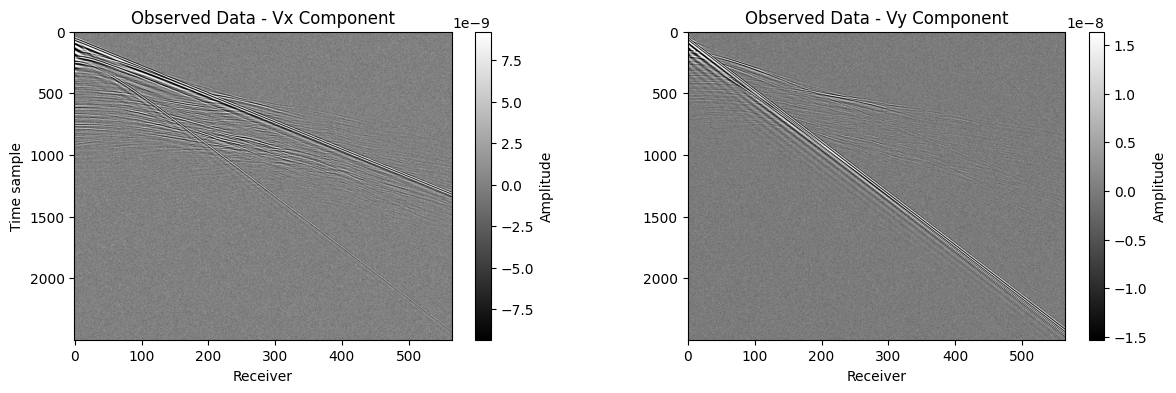

In [6]:
Physics = Physics_deepwave
DT = 0.006
F_PEAK = 8
DH = dx
use_est_source = 'yes'

inpa = {                                  
    'fdom': F_PEAK, 
    'dh': DH,   
    'dt': DT
}

NT = 2500#int( Decimal(t_in) // Decimal(dt_in)  + 1)
print("NT:",NT)

### LOAD DATA 

d_obs_vx_fine = torch.tensor(np.load('./obs_data/d_obs_vx_src.npy'))
d_obs_vy_fine = torch.tensor(np.load('./obs_data/d_obs_vy_src.npy'))

print(d_obs_vy_fine.shape)

d_obs_vx = d_obs_vx_fine[:,::2,:,::2]
d_obs_vy = d_obs_vy_fine[:,::2,:,::2]


print(d_obs_vx.shape)

p=0
fig, ax = plot_observed_data(d_obs_vx, d_obs_vy, p,'cpu')


In [7]:
## locations ## source 
src_loc_fine = torch.tensor(np.load('./src_rec_positions/src_loc.npy'))
rec_loc_fine = torch.tensor(np.load('./src_rec_positions/rec_loc.npy'))
src_fine = torch.tensor(np.load('./sources/src.npy'))

src_loc_select = src_loc_fine[::2]/2
rec_loc_select = rec_loc_fine[::2,::2]/2
src_select = src_fine[::2]
print(rec_loc_select.shape)

model_shape_new = [vp_true.shape[0], vp_true.shape[1]]

## interpolation to rrid point
from deepwave.location_interpolation import Hicks
model_shape_new = [vp_initial.shape[0], vp_initial.shape[1]]

rec_interp = Hicks(
    locations=rec_loc_select,
    halfwidth=4,
    free_surfaces=[True, False, False, True],
    model_shape=model_shape_new,
    monopole=True,
    dtype=torch.float,
    eps=1e-5
)

src_interp = Hicks(
    locations=src_loc_select,
    halfwidth=4,
    free_surfaces=[True, False, False, True],
    model_shape=model_shape_new,
    monopole=True,
    dtype=torch.float,
    eps=1e-5
)

## here we use hicks only for source estimation

src_loc_hicks_src = src_interp.get_locations().to(DEVICE)
rec_loc_hicks_src = rec_interp.get_locations().to(DEVICE)
src_hicks_src = src_interp.source(src_select).to(DEVICE)
## SHOW DATA 
print('hicks souurce lacations shape',src_loc_hicks_src.shape)
print('hicks receiver lacations shape',rec_loc_hicks_src.shape)
print('hicks souurce shape',src_hicks_src.shape)


torch.Size([50, 565, 2])
hicks souurce lacations shape torch.Size([50, 40, 2])
hicks receiver lacations shape torch.Size([50, 565, 2])
hicks souurce shape torch.Size([50, 40, 2500])


In [8]:
##### source estmation
inpa.update({
    'nr': d_obs_vx.shape[3],
    'nt': d_obs_vx.shape[2],
     'dt':0.006,
    'dh': DH, 
    'ns':d_obs_vx.shape[1],
    'ns_per_shot': src_loc_hicks_src.shape[1]
})


if use_est_source == 'yes':
    source_file = './sources/source_est.npy'
    try:
        if os.path.exists(source_file):
            src = torch.tensor(np.load(source_file)).to(DEVICE)
            print(f"loading data: {source_file}")
        else:
            raise FileNotFoundError("data does not exist")
    except (FileNotFoundError, IOError) as e:
        print(f"Failed to load data: {e}")
        print("Source wavelet is being generated...")
        src = estimate_source_wavelet_elastic(vp_initial = vp_initial.detach().clone(), 
                                          vs_initial = vs_initial.detach().clone(), 
                                          rho_initial = rho_initial.detach().clone(), 
                                      obs_data  = d_obs_vx.squeeze(0).detach().clone(),  
                                      src_loc = src_loc_hicks_src, 
                                      rec_loc = rec_loc_hicks_src, 
                                     rec_interp = rec_interp,
                                      inpa = inpa, 
                                      Physics = Physics_deepwave, 
                                      DEVICE = DEVICE)
        src = src.unsqueeze(1).to(DEVICE) 
        print(src.shape)
        os.makedirs(os.path.dirname(source_file), exist_ok=True)
        np.save(source_file, src.detach().cpu().numpy())
else:
    src = src_select


loading data: ./sources/source_est.npy


Encoded observation data shape (vx): torch.Size([10, 2500, 565])
Encoded observation data shape (vy): torch.Size([10, 2500, 565])
Encoded source location shape: torch.Size([10, 5, 2])
Encoded receiver location shape: torch.Size([10, 565, 2])
Encoded source function shape: torch.Size([10, 5, 2500])
hicks souurce lacations shape torch.Size([10, 165, 2])
hicks receiver lacations shape torch.Size([10, 565, 2])
hicks souurce shape torch.Size([10, 165, 2500])
Data shape - Vx: torch.Size([10, 2500, 565]), Vy: torch.Size([10, 2500, 565])


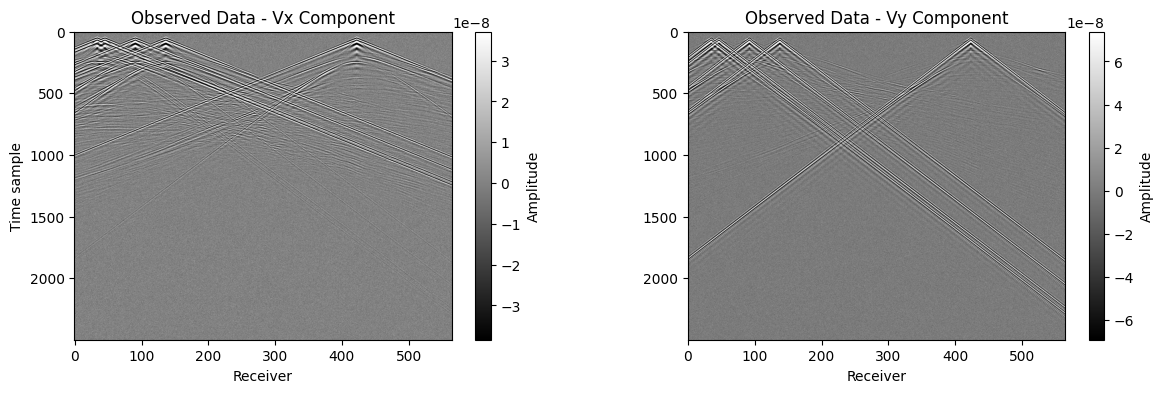

In [9]:
num_super_sources = 10
sources_per_super = 5
source_distribution = 'random'# ('random' 或 'uniform')

#### 1. 先编码，在插值
result = encode_sources(obs_data_vx = d_obs_vx.squeeze(0),
                        obs_data_vy = d_obs_vy.squeeze(0),
                        source_locations = src_loc_select, 
                        receiver_locations  = rec_loc_select, 
                        source_functions = src,
                        num_super_sources = num_super_sources,
                        sources_per_super = sources_per_super,
                        source_distribution=source_distribution
                        )

# 检查结果形状
print(f"Encoded observation data shape (vx): {result['encoded_obs_data_vx'].shape}")
print(f"Encoded observation data shape (vy): {result['encoded_obs_data_vy'].shape}")
print(f"Encoded source location shape: {result['encoded_source_locations'].shape}")
print(f"Encoded receiver location shape: {result['encoded_receiver_locations'].shape}")
print(f"Encoded source function shape: {result['encoded_source_functions'].shape}")


d_obs_vx_encode = result['encoded_obs_data_vx'].unsqueeze(0).to(DEVICE)
d_obs_vy_encode = result['encoded_obs_data_vy'].unsqueeze(0).to(DEVICE)
src_loc_encode  = result['encoded_source_locations'].to(DEVICE)
rec_loc_encode  = result['encoded_receiver_locations'].to(DEVICE)
src_encode      = result['encoded_source_functions'].to(DEVICE)

groups = result['groups']


#2.再插值

rec_interp = Hicks(
    locations=rec_loc_encode,
    halfwidth=4,
    free_surfaces=[True, False, False, True],
    model_shape=model_shape_new,
    monopole=True,
    dtype=torch.float,
    eps=1e-5
)

src_interp = Hicks(
    locations=src_loc_encode,
    halfwidth=4,
    free_surfaces=[True, False, False, True],
    model_shape=model_shape_new,
    monopole=True,
    dtype=torch.float,
    eps=1e-5
)

src_loc_hicks = src_interp.get_locations().to(DEVICE)
rec_loc_hicks = rec_interp.get_locations().to(DEVICE)
src_hicks = src_interp.source(src_encode).to(DEVICE)

print('hicks souurce lacations shape',src_loc_hicks.shape)
print('hicks receiver lacations shape',rec_loc_hicks.shape)
print('hicks souurce shape',src_hicks.shape)

p = 2

fig, ax = plot_observed_data(d_obs_vx_encode, d_obs_vy_encode, p, DEVICE)

In [10]:
vp_initial = vp_initial.to(DEVICE)
vs_initial = vs_initial.to(DEVICE)
rho_initial = rho_initial.to(DEVICE)
vp = vp_initial.requires_grad_(True)
vs = vs_initial.requires_grad_(True)
rho = rho_initial.requires_grad_(True)
src_init = src.requires_grad_(True)

criteria = torch.nn.L1Loss(reduction='sum')
criteria_model = torch.nn.L1Loss(reduction='sum')

optimer = torch.optim.Adam([{'params': [vp], 'lr': 8.0},
                            {'params': [vs], 'lr': 4.0},
                            {'params': [rho], 'lr': 2.0},
                           {'params': [src_init],'lr': 1.0e-3}])

import torch.optim.lr_scheduler as lr_scheduler
scheduler = lr_scheduler.StepLR(optimer, step_size=150, gamma=0.2)

In [11]:
all_loss_data = []
all_loss_vx_model = []
all_loss_vy_model = []
all_loss_rho_model = []
all_loss_model =[]
SNR_vp = []
SSIM_vp = []
Loss_vp = []
ERROR_vp = []
SNR_vs = []
SSIM_vs = []
Loss_vs = []
ERROR_vs = []
SNR_rho = []
SSIM_rho = []
Loss_rho = []
ERROR_rho = []
time_each_iter = []
def get_cpu_memory():
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    return mem_info.rss / 1024 ** 2   # 转为 MB
    
def get_gpu_memory():
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 ** 2
    else:
        return 0
cpu_mem_log = [] 
gpu_mem_log = []

Iter 5 = loss: 12.0947,model loss: 45776239.00,time:5.90,snr_vp:19.401,snr_vs:19.247,snr_rho:24.509
Iter 10 = loss: 11.1220,model loss: 45704081.00,time:6.64,snr_vp:19.463,snr_vs:19.232,snr_rho:24.535
Iter 15 = loss: 10.4730,model loss: 45807567.00,time:7.12,snr_vp:19.494,snr_vs:19.217,snr_rho:24.543
Iter 20 = loss: 9.9814,model loss: 45916501.00,time:6.91,snr_vp:19.517,snr_vs:19.206,snr_rho:24.538


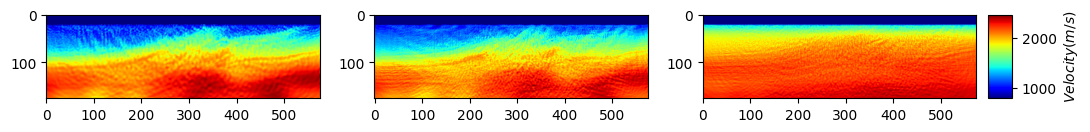

Iter 25 = loss: 9.6523,model loss: 46001143.00,time:6.82,snr_vp:19.538,snr_vs:19.202,snr_rho:24.525
Iter 30 = loss: 9.3968,model loss: 45998864.00,time:7.69,snr_vp:19.568,snr_vs:19.207,snr_rho:24.508
Iter 35 = loss: 9.2179,model loss: 45978051.00,time:8.39,snr_vp:19.603,snr_vs:19.219,snr_rho:24.490
Iter 40 = loss: 9.1320,model loss: 45943704.00,time:7.50,snr_vp:19.634,snr_vs:19.232,snr_rho:24.472


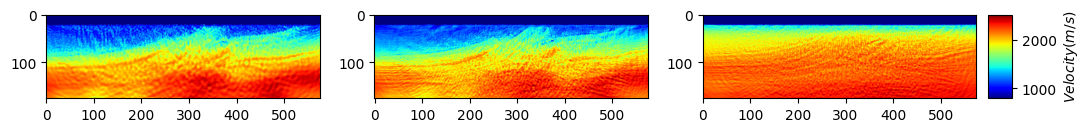

Iter 45 = loss: 9.0062,model loss: 45903670.00,time:7.98,snr_vp:19.663,snr_vs:19.247,snr_rho:24.454
Iter 50 = loss: 8.9227,model loss: 45858088.00,time:7.83,snr_vp:19.691,snr_vs:19.262,snr_rho:24.437
Iter 55 = loss: 8.8718,model loss: 45798996.00,time:7.78,snr_vp:19.721,snr_vs:19.278,snr_rho:24.417
Iter 60 = loss: 8.8225,model loss: 45750901.00,time:6.80,snr_vp:19.750,snr_vs:19.291,snr_rho:24.392


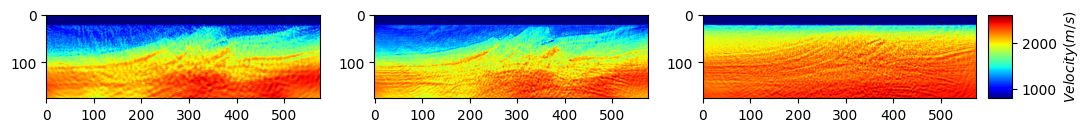

Iter 65 = loss: 8.7759,model loss: 45734311.00,time:6.39,snr_vp:19.776,snr_vs:19.297,snr_rho:24.361
Iter 70 = loss: 8.7543,model loss: 45733415.00,time:6.47,snr_vp:19.800,snr_vs:19.298,snr_rho:24.325
Iter 75 = loss: 8.7233,model loss: 45739727.00,time:6.12,snr_vp:19.823,snr_vs:19.295,snr_rho:24.284
Iter 80 = loss: 8.6900,model loss: 45770621.00,time:6.08,snr_vp:19.843,snr_vs:19.287,snr_rho:24.239


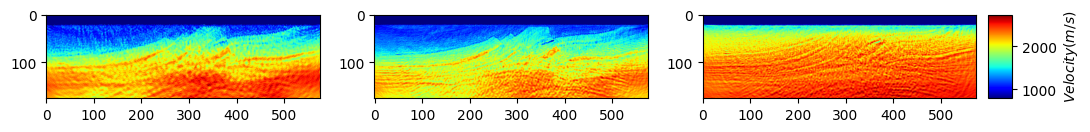

Iter 85 = loss: 8.6947,model loss: 45816665.00,time:6.34,snr_vp:19.861,snr_vs:19.275,snr_rho:24.191
Iter 90 = loss: 8.6703,model loss: 45865251.00,time:6.24,snr_vp:19.879,snr_vs:19.261,snr_rho:24.140
Iter 95 = loss: 8.6567,model loss: 45932288.00,time:6.25,snr_vp:19.894,snr_vs:19.243,snr_rho:24.087
Iter 100 = loss: 8.6536,model loss: 46015899.00,time:6.28,snr_vp:19.905,snr_vs:19.223,snr_rho:24.031


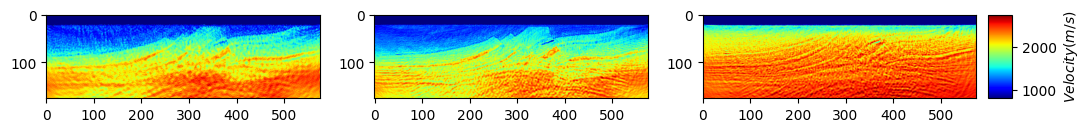

Epoch 99: Learning rates = [8.0, 4.0, 2.0, 0.001]
Iter 105 = loss: 8.6404,model loss: 46106774.00,time:6.33,snr_vp:19.916,snr_vs:19.203,snr_rho:23.974
Iter 110 = loss: 8.6300,model loss: 46196025.00,time:6.27,snr_vp:19.925,snr_vs:19.183,snr_rho:23.917
Iter 115 = loss: 8.6264,model loss: 46294803.00,time:6.16,snr_vp:19.932,snr_vs:19.161,snr_rho:23.859
Iter 120 = loss: 8.6254,model loss: 46405769.00,time:6.10,snr_vp:19.937,snr_vs:19.138,snr_rho:23.800


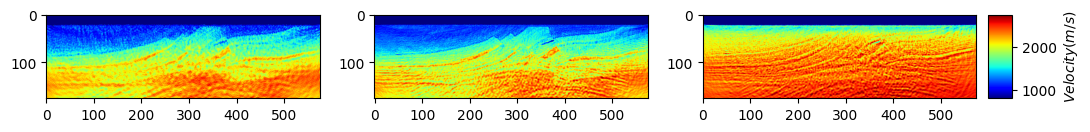

Iter 125 = loss: 8.6261,model loss: 46530082.00,time:6.28,snr_vp:19.938,snr_vs:19.113,snr_rho:23.741
Iter 130 = loss: 8.6195,model loss: 46646856.00,time:6.21,snr_vp:19.939,snr_vs:19.090,snr_rho:23.683
Iter 135 = loss: 8.6072,model loss: 46757723.00,time:6.27,snr_vp:19.940,snr_vs:19.067,snr_rho:23.625
Iter 140 = loss: 8.6052,model loss: 46879658.00,time:6.30,snr_vp:19.939,snr_vs:19.044,snr_rho:23.567


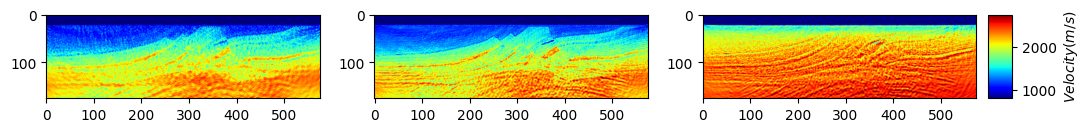

Iter 145 = loss: 8.5983,model loss: 47003530.00,time:6.23,snr_vp:19.936,snr_vs:19.019,snr_rho:23.510
Iter 150 = loss: 8.6054,model loss: 47130602.00,time:6.29,snr_vp:19.932,snr_vs:18.995,snr_rho:23.453
Iter 155 = loss: 8.5359,model loss: 47098138.00,time:6.23,snr_vp:19.930,snr_vs:18.989,snr_rho:23.442
Iter 160 = loss: 8.5348,model loss: 47133986.00,time:6.31,snr_vp:19.927,snr_vs:18.982,snr_rho:23.431


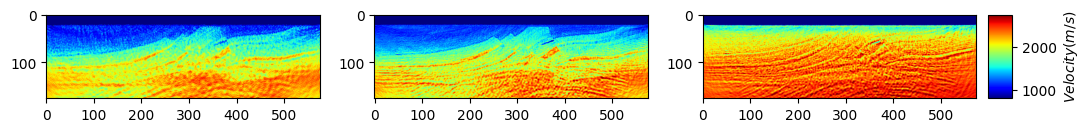

Iter 165 = loss: 8.5339,model loss: 47170411.00,time:6.54,snr_vp:19.924,snr_vs:18.975,snr_rho:23.419
Iter 170 = loss: 8.5333,model loss: 47206657.00,time:6.18,snr_vp:19.921,snr_vs:18.968,snr_rho:23.407


In [ ]:
# Run optimisation/inversion

t_start = time.time()
mini_batches = 5
ITERATION = 300 

import time
t_start = time.time()

for iter in range(ITERATION):
    loss_data_minibatch = []
    
    time_each_bath_start = time.time()
    for batch in range(mini_batches):
        loss_freqs = []
   
        optimer.zero_grad()
    
        encoded_source_fun = encode_source_functions_only(src_init, groups)

        src_hicks_1 = src_interp.source(encoded_source_fun.to(DEVICE)).to(DEVICE)
        src_loc_batch = src_loc_hicks[batch::mini_batches].to(DEVICE)
        rec_loc_batch = rec_loc_hicks[batch::mini_batches].to(DEVICE)
        src_batch = src_hicks_1[batch::mini_batches].to(DEVICE) ## for true source
            
        physics = Physics(inpa['dh'], inpa['dt'],inpa['fdom'],inpa['nt'],src=src_batch,
                    src_loc=src_loc_batch, rec_loc=rec_loc_batch
                    )
        with torch.no_grad():
            vp[:submarine_deep,:] = submarine_vp
            vs[:submarine_deep,:] = submarine_vs
            rho[:submarine_deep,:] = submarine_rho
         
            vp[vp>vp_true.max()] = vp_true.max()
            vp[vp<vp_true.min()] = vp_true.min()
    
            vs[vs>vs_true.max()] = vs_true.max()
            vs[vs<vs_true.min()] = vs_true.min()
    
            rho[rho>rho_true.max()] = rho_true.max()
            rho[rho<rho_true.min()] = rho_true.min()
           
            vp = vp.requires_grad_(True)
            vs = vs.requires_grad_(True)
            rho = rho.requires_grad_(True)          
    
        vp = vp.to(DEVICE)
        vs = vs.to(DEVICE)
        rho = rho.to(DEVICE)
        

        taux_est = physics(vp,vs,rho) 
        taux_vx_est_filtered = rec_interp.receiver(taux_est[0].squeeze(0).cpu().permute(0, 2, 1)).permute(0, 2, 1).unsqueeze(0).to(DEVICE)
        taux_vy_est_filtered = rec_interp.receiver(taux_est[1].squeeze(0).cpu().permute(0, 2, 1)).permute(0, 2, 1).unsqueeze(0).to(DEVICE)
        
        taux_est_all = torch.cat((taux_vx_est_filtered,taux_vy_est_filtered),dim=1).to(DEVICE)
        
        #print(taux_est_all)
        d_obs_vx_filtered = d_obs_vx_encode[:, batch::mini_batches].to(DEVICE)
        d_obs_vy_filtered = d_obs_vy_encode[:, batch::mini_batches].to(DEVICE)
        
        d_obs_filtered_all = torch.cat((d_obs_vx_filtered,d_obs_vy_filtered),dim=1).to(DEVICE)
    
        criteria = torch.nn.L1Loss(reduction='mean')
        loss_data = 1.0e9*criteria(taux_est_all, d_obs_filtered_all) 
       
        loss = loss_data
    
        loss.backward()
        
        optimer.step()
    
        loss_freqs.append(loss_data.cpu().detach().numpy())
        loss_data_minibatch.append(np.mean(loss_freqs))
    all_loss_data.append(loss_data.detach().cpu().item())
    time_each_bath_end = time.time()
    time_each_iter.append(time_each_bath_end - time_each_bath_start)
   
        
    mem_now_cpu = get_cpu_memory()
    cpu_mem_log.append(mem_now_cpu)
    mem_now_gpu = get_gpu_memory()
    gpu_mem_log.append(mem_now_gpu)
    
    with torch.no_grad():
        all_loss_vx_model.append(
            criteria_model(vp.cpu(),vp_true.cpu()).detach().numpy().item()
        )
    
        all_loss_vy_model.append(
            criteria_model(vs.cpu(),vs_true.cpu()).detach().numpy().item()
            )
        all_loss_rho_model.append(
            criteria_model(rho.cpu(),rho_true.cpu()).detach().numpy().item()
        )
        all_loss_model.append(
            criteria_model(vp, vp_true).item()+ criteria_model(vs, vs_true).item()+ criteria_model(rho, rho_true).item()
        )

    snr_vp = ComputeSNR(vp.detach().cpu().numpy(), \
              vp_true.detach().cpu().numpy())
    SNR_vp = np.append(SNR_vp, snr_vp)
    snr_vs = ComputeSNR(vs.detach().cpu().numpy(), \
              vs_true.detach().cpu().numpy())
    SNR_vs = np.append(SNR_vs, snr_vs)
    snr_rho = ComputeSNR(rho.detach().cpu().numpy(), \
              rho_true.detach().cpu().numpy())
    SNR_rho = np.append(SNR_rho, snr_rho)

    if (iter+1)%5 == 0:
        print(f"Iter {iter + 1} = loss: {all_loss_data[-1]:.4f},model loss: {all_loss_model[-1]:.2f},time:{time_each_iter[-1]:.2f},snr_vp:{SNR_vp[-1]:.3f},snr_vs:{SNR_vs[-1]:.3f},snr_rho:{SNR_rho[-1]:.3f}")
    if (iter+1)%10==0:
        np.save(vp_save_path + 'recx_iter_%s.npy' % (iter + 1), vp.cpu().detach().numpy())
        np.save(vs_save_path + 'recx_iter_%s.npy' % (iter + 1), vs.cpu().detach().numpy())
        np.save(rho_save_path + 'recx_iter_%s.npy' % (iter + 1), rho.cpu().detach().numpy())
        np.save(src_save_path + 'recx_iter_%s.npy' % (iter + 1), src_init.cpu().detach().numpy())
    if (iter+1)%20 == 0:
        fig, ax = plt.subplots(1,3,figsize=(12, 6))
        im0 = ax[0].imshow(vp.squeeze(0).detach().cpu(), 
                      cmap="jet") 
        im1 = ax[1].imshow(vs.squeeze(0).detach().cpu(), 
                      cmap="jet") 
        im2 = ax[2].imshow(rho.squeeze(0).detach().cpu(), 
                      cmap="jet") 
        points = ax[1].get_position().get_points()
        dy = points[1, 1] - points[0, 1]
        cax = fig.add_axes([0.91, points[0, 1], 0.02, dy])
        cax.yaxis.set_ticks_position("right")
        cbar = fig.colorbar(im1, cax=cax, orientation="vertical", 
                        extend="neither", label="$Velocity (m/s)$"
                        )
        plt.show()
    scheduler.step() 
    if (iter+1) % 100 == 0:
        current_lrs = [group['lr'] for group in optimer.param_groups]
        print(f'Epoch {iter}: Learning rates = {current_lrs}')
t_end = time.time()
elapsed_time = t_end - t_start
print('Running complete in {:.0f}m  {:.0f}s' .format(elapsed_time //60 , elapsed_time % 60))

In [ ]:

with torch.no_grad():
    
    np.savetxt(main_path+'all_loss_data.txt', all_loss_data,delimiter=',')
    np.savetxt(main_path+'all_loss_model.txt', all_loss_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vp_model.txt', all_loss_vx_model, delimiter=',')
    np.savetxt(main_path+'all_loss_vs_model.txt', all_loss_vy_model, delimiter=',')
    np.savetxt(main_path+'all_loss_rho_model.txt', all_loss_rho_model, delimiter=',')
    
    np.savetxt(main_path+'vp_snr.txt', SNR_vp,delimiter=',')
    np.savetxt(main_path+'vs_snr.txt', SNR_vs,delimiter=',')
    np.savetxt(main_path+'rho_snr.txt', SNR_rho,delimiter=',')
    
    np.savetxt(main_path+'time.txt',time_each_iter , delimiter=',')
    
    np.savetxt(main_path+'cpu_men_log.txt',cpu_mem_log , delimiter=',')
    np.savetxt(main_path+'gpu_men_log.txt',gpu_mem_log , delimiter=',')
